# CF metagenome analysis

In [1]:
### load packages
import math
import glob
import gzip

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import pyarrow as pa
import seaborn as sns
import shap

from scipy.stats import spearmanr, pearsonr, fisher_exact
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    roc_curve,
    precision_recall_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from statsmodels.stats.multitest import multipletests

plt.rcParams.update({'font.size': 14})

/gscratch/pedslabs_hoffman/carsonjm/micromamba_envs/envs/lgonsa/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
### Load input files
uhvdb_final_metadata = pl.read_csv('../figure_s17/uhvdb_v5_final_metadata_v2.tsv', separator='\t')
genome_to_species = uhvdb_final_metadata.select(['uhvdb_id', 'species_cluster_id']).unique()
read_depth = (
    pl.read_csv('cf_metag_read_depth.txt.gz', separator='\t', has_header=False)
        .rename({'column_1': 'sample_id', 'column_2': 'read_depth'})
)
coverm = pl.read_csv('cf_metag_coverm_results.tsv.gz', separator='\t')
sylph_tax = pl.read_csv('cf_metag_sylph_tax_results.tsv.gz', separator='\t')

classify = pl.read_csv('cf_metag_results/2026-04-08_outputs/classify/new_mq_plus_classify_2.tsv.gz', separator='\t')
vclust = pl.read_csv('cf_metag_results/2026-04-08_outputs/assemblyanalyze/vclust_new2all/new_mq_plus_viruses/new_mq_plus_viruses_2.ani.tsv.gz', separator='\t')
propagate = pl.read_csv('cf_metag_propagate.tsv.gz', separator='\t')
mvirs = pl.read_csv('cf_metag_mvirs.tsv.gz', separator='\t')

Total CF metagenomes preprocessed:  1959
Minimum read depth:  0.042456  megabase pairs (Mbp)
Maximum read depth:  25230.716814  megabase pairs (Mbp)


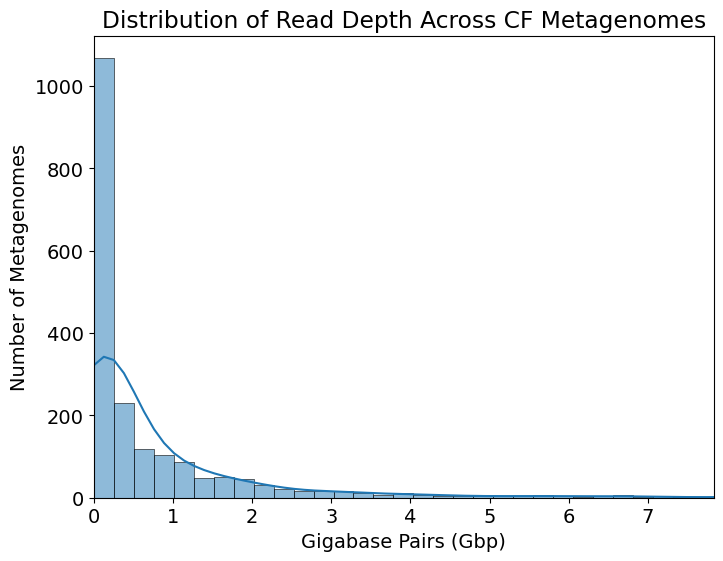

In [3]:
### Plot the distribution of read depth across all CF metagenomes
print("Total CF metagenomes preprocessed: ", read_depth.shape[0])
print("Minimum read depth: ", read_depth['read_depth'].min()/1e6, " megabase pairs (Mbp)")
print("Maximum read depth: ", read_depth['read_depth'].max()/1e6, " megabase pairs (Mbp)")

read_depth_plot = (
    read_depth
        .with_columns((pl.col('read_depth') / 1e9).alias('read_depth_gbp'))
)

plt.figure(figsize=(8, 6))
sns.histplot(read_depth_plot['read_depth_gbp'], bins=100, kde=True)
plt.xlabel('Gigabase Pairs (Gbp)')
plt.ylabel('Number of Metagenomes')
plt.title('Distribution of Read Depth Across CF Metagenomes')
plt.xlim(0, read_depth_plot['read_depth_gbp'].quantile(0.99))
plt.show()

Number of CF metagenomes with sylph UHVDB species:  1809
Number of detected UHVDB species:  17457
Minimum UHVDB species richness:  1
Median UHVDB species richness:  21.0
Mean UHVDB species richness:  40.039248203427306
Maximum UHVDB species richness:  319


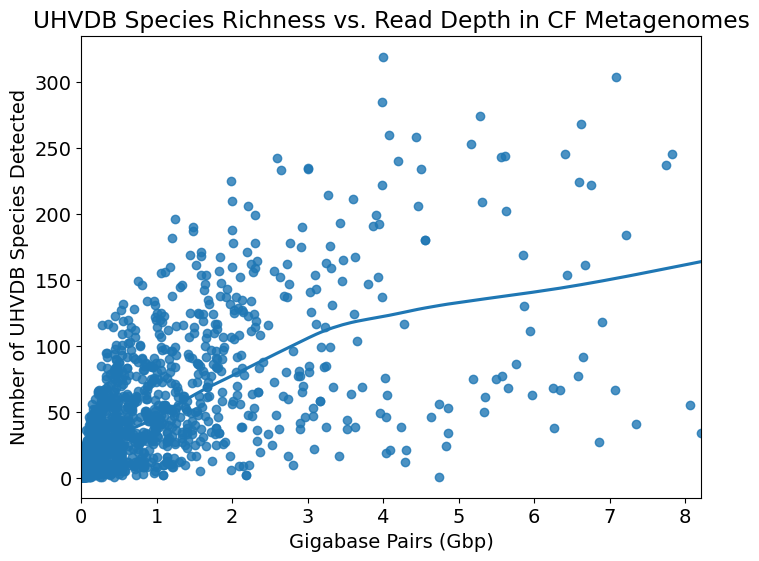

In [4]:
### Plot the number of UHVDB species detected by sylph by read depth
sylph_species = sylph_tax.filter(pl.col('clade_name').str.contains(r'vSPECIES-.*\|t__'))
print("Number of CF metagenomes with sylph UHVDB species: ", sylph_species['sample_id'].n_unique())
print("Number of detected UHVDB species: ", sylph_species['clade_name'].n_unique())

sylph_species_richness = (
    sylph_species
        .group_by('sample_id')
        .agg(pl.col('clade_name').n_unique().alias('species_richness'))
        .join(read_depth_plot, on='sample_id')
)
print("Minimum UHVDB species richness: ", sylph_species_richness['species_richness'].min())
print("Median UHVDB species richness: ", sylph_species_richness['species_richness'].median())
print("Mean UHVDB species richness: ", sylph_species_richness['species_richness'].mean())
print("Maximum UHVDB species richness: ", sylph_species_richness['species_richness'].max())

plt.figure(figsize=(8, 6))
sns.regplot(data=sylph_species_richness, x='read_depth_gbp', y='species_richness', lowess=True)
plt.xlabel('Gigabase Pairs (Gbp)')
plt.ylabel('Number of UHVDB Species Detected')
plt.title('UHVDB Species Richness vs. Read Depth in CF Metagenomes')
plt.xlim(0, sylph_species_richness['read_depth_gbp'].quantile(0.99))
plt.show()

Number of CF metagenomes with CoverM UHVDB species:  1809
Number of CF metagenomes with CoverM UHVDB species:  17456
R-squared between Sylph coverage and CoverM trimmed mean:  0.7647342326170984
Proportion of incongruities (> 2x difference): 0.3108337590258315
Proportion of incongruities (> 5x difference): 0.051469674586848174


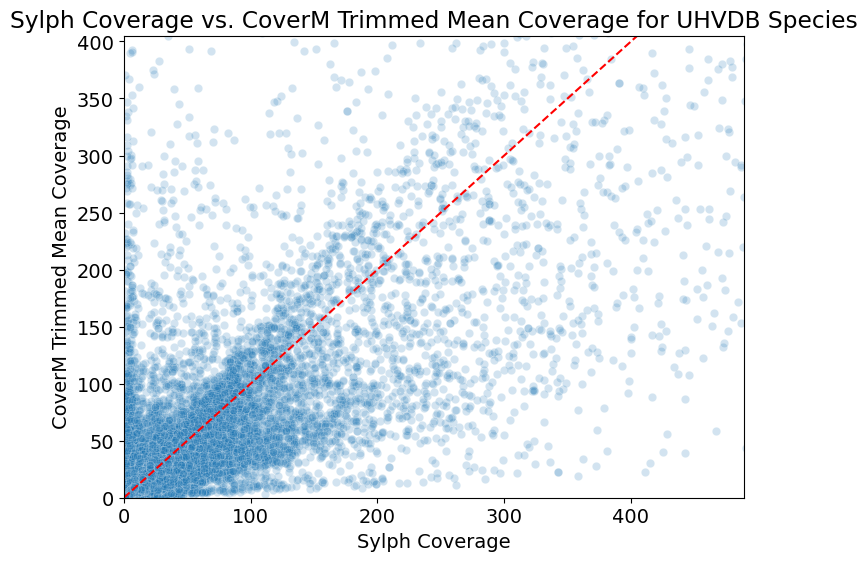

In [5]:
### Plot CoverM coverage vs sylph coverage
print("Number of CF metagenomes with CoverM UHVDB species: ", coverm.filter(pl.col('trimmed_mean') > 0)['sample_id'].n_unique())
print("Number of CF metagenomes with CoverM UHVDB species: ", coverm.filter(pl.col('trimmed_mean') > 0)['contig_id'].n_unique())


sylph_v_coverm = (
    sylph_species
        .select(['sample_id', 'clade_name', 'coverage'])
        .with_columns(pl.col('clade_name').str.split('t__').list[-1].alias('contig_id'))
        .join(coverm.select(['contig_id', 'sample_id', 'trimmed_mean']), on=['sample_id', 'contig_id'], how='full')
)

# calculate R-squared between sylph coverage and coverm trimmed mean
sylph_v_coverm = sylph_v_coverm.filter(pl.col('coverage').is_not_null() & pl.col('trimmed_mean').is_not_null())
correlation = sylph_v_coverm.select(pl.corr('coverage', 'trimmed_mean')).item()
r_squared = correlation ** 2
print("R-squared between Sylph coverage and CoverM trimmed mean: ", r_squared)
print("Proportion of incongruities (> 2x difference):",
    sylph_v_coverm
        .with_columns((pl.col('trimmed_mean') / pl.col('coverage')).alias('coverm_sylph_ratio'))
        .filter((pl.col('coverm_sylph_ratio') > 2) | (pl.col('coverm_sylph_ratio') < 0.5))
        .height / sylph_v_coverm.height
)
print("Proportion of incongruities (> 5x difference):",
    sylph_v_coverm
        .with_columns((pl.col('trimmed_mean') / pl.col('coverage')).alias('coverm_sylph_ratio'))
        .filter((pl.col('coverm_sylph_ratio') > 5) | (pl.col('coverm_sylph_ratio') < 0.2))
        .height / sylph_v_coverm.height
)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=sylph_v_coverm, x='coverage', y='trimmed_mean', alpha=0.2)
plt.xlabel('Sylph Coverage')
plt.ylabel('CoverM Trimmed Mean Coverage')
plt.title('Sylph Coverage vs. CoverM Trimmed Mean Coverage for UHVDB Species')
plt.xlim(0, sylph_v_coverm['coverage'].quantile(0.99))
plt.ylim(0, sylph_v_coverm['trimmed_mean'].quantile(0.99))
# add a y=x line for reference
max_val = max(sylph_v_coverm['coverage'].quantile(0.99), sylph_v_coverm['trimmed_mean'].quantile(0.99))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')
plt.show()

,trimmed_mean,n_points,r_squared
0,0.5,67409,0.764531
1,1.0,57670,0.764073
2,1.5,50021,0.763686
3,2.0,43959,0.766902
4,2.5,39300,0.766983
5,3.0,36356,0.770681
6,3.5,34610,0.770847
7,4.0,33128,0.770958
8,4.5,31564,0.771267
9,5.0,29899,0.772969


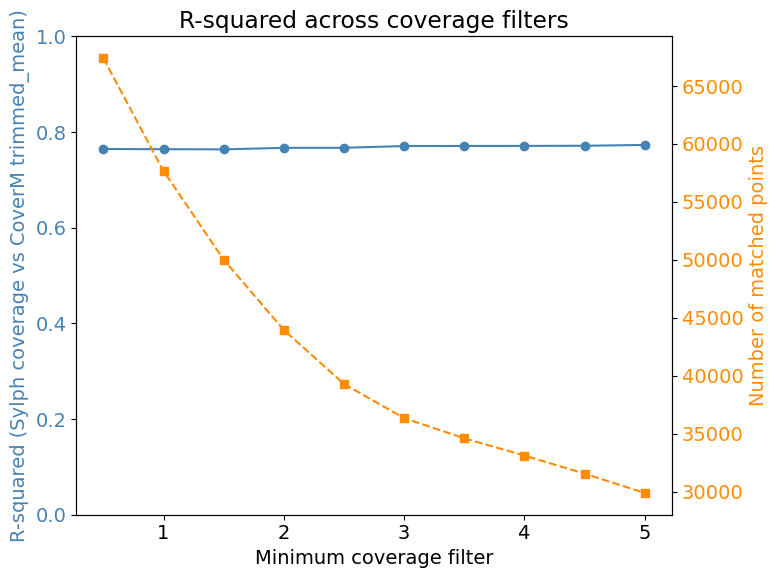

In [6]:
### Plot CoverM coverage vs sylph coverage R-squared using different breadth_ratio filters
# Build merged table once
sylph_v_coverm = (
    sylph_species
        .select(['sample_id', 'clade_name', 'coverage'])
        .with_columns(pl.col('clade_name').str.split('t__').list[-1].alias('contig_id'))
        .join(
            coverm.select(['contig_id', 'sample_id', 'trimmed_mean', 'breadth_ratio']),
            on=['sample_id', 'contig_id'],
            how='full'
        )
        .filter(
            pl.col('coverage').is_not_null()
            & pl.col('trimmed_mean').is_not_null()
            & pl.col('breadth_ratio').is_not_null()
        )
)

coverage_filters = [0.50, 1.0, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5]
results = []

for br in coverage_filters:
    df = sylph_v_coverm.filter(pl.col('coverage') >= br)
    n = df.height
    if n >= 3:
        corr = df.select(pl.corr('coverage', 'trimmed_mean')).item()
        r2 = (corr ** 2) if corr is not None else np.nan
    else:
        r2 = np.nan
    results.append({'trimmed_mean': br, 'n_points': n, 'r_squared': r2})

r2_df = pd.DataFrame(results)
display(r2_df)

fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(r2_df['trimmed_mean'], r2_df['r_squared'], marker='o', color='steelblue')
ax1.set_xlabel('Minimum coverage filter')
ax1.set_ylabel('R-squared (Sylph coverage vs CoverM trimmed_mean)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
ax2.plot(r2_df['trimmed_mean'], r2_df['n_points'], marker='s', linestyle='--', color='darkorange')
ax2.set_ylabel('Number of matched points', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('R-squared across coverage filters')
plt.tight_layout()
plt.show()

,breadth_ratio_min,n_points,r_squared
0,0.00,72431,0.764734
1,0.05,72431,0.764734
2,0.10,72431,0.764734
3,0.20,72298,0.766997
4,0.30,71061,0.777939
5,0.40,66644,0.806884
6,0.50,61651,0.878367
7,0.60,55151,0.893042
8,0.70,45923,0.906556
9,0.80,33137,0.919030


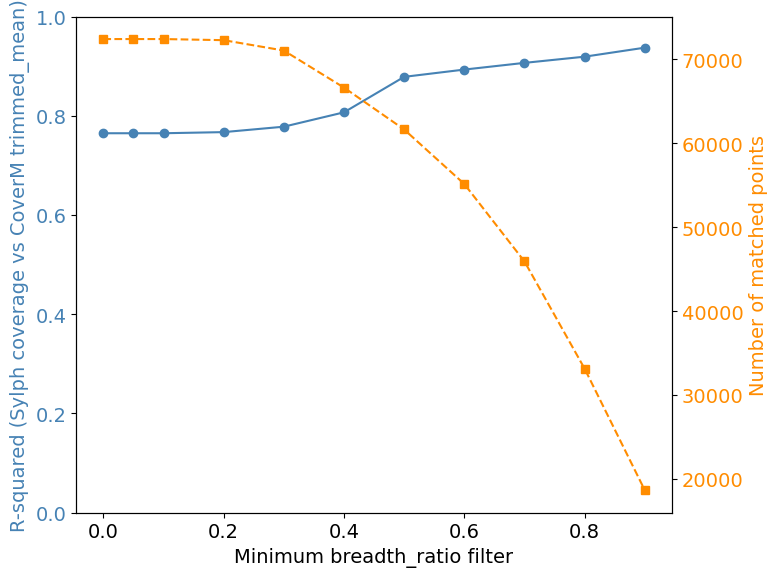

In [10]:
### Plot CoverM coverage vs sylph coverage R-squared using different breadth_ratio filters
# Build merged table once
sylph_v_coverm = (
    sylph_species
        .select(['sample_id', 'clade_name', 'coverage'])
        .with_columns(pl.col('clade_name').str.split('t__').list[-1].alias('contig_id'))
        .join(
            coverm.select(['contig_id', 'sample_id', 'trimmed_mean', 'breadth_ratio']),
            on=['sample_id', 'contig_id'],
            how='full'
        )
        .filter(
            pl.col('coverage').is_not_null()
            & pl.col('trimmed_mean').is_not_null()
            & pl.col('breadth_ratio').is_not_null()
        )
)

breadth_filters = [0.0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
results = []

for br in breadth_filters:
    df = sylph_v_coverm.filter(pl.col('breadth_ratio') >= br)
    n = df.height
    if n >= 3:
        corr = df.select(pl.corr('coverage', 'trimmed_mean')).item()
        r2 = (corr ** 2) if corr is not None else np.nan
    else:
        r2 = np.nan
    results.append({'breadth_ratio_min': br, 'n_points': n, 'r_squared': r2})

r2_df = pd.DataFrame(results)
display(r2_df)

fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(r2_df['breadth_ratio_min'], r2_df['r_squared'], marker='o', color='steelblue')
ax1.set_xlabel('Minimum breadth_ratio filter')
ax1.set_ylabel('R-squared (Sylph coverage vs CoverM trimmed_mean)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
ax2.plot(r2_df['breadth_ratio_min'], r2_df['n_points'], marker='s', linestyle='--', color='darkorange')
ax2.set_ylabel('Number of matched points', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.tight_layout()
plt.show()

,breadth_ratio_min,n_points,num_spurious
0,0.00,72431,0.310834
1,0.05,72431,0.310834
2,0.10,72431,0.310834
3,0.20,72298,0.309760
4,0.30,71061,0.300559
5,0.40,66644,0.276529
6,0.50,61651,0.254465
7,0.60,55151,0.232888
8,0.70,45923,0.207891
9,0.80,33137,0.186287


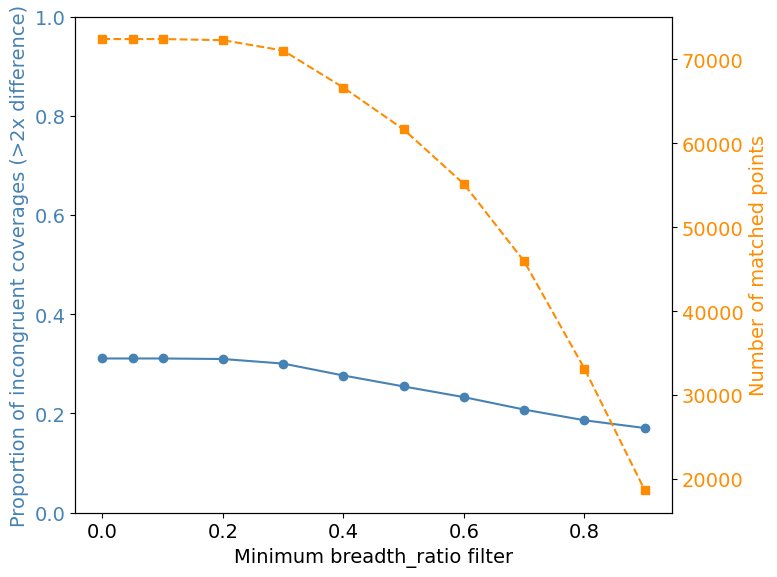

In [12]:
### Plot CoverM coverage vs sylph coverage R-squared using different breadth_ratio filters
# Build merged table once
sylph_v_coverm = (
    sylph_species
        .select(['sample_id', 'clade_name', 'coverage'])
        .with_columns(pl.col('clade_name').str.split('t__').list[-1].alias('contig_id'))
        .join(
            coverm.select(['contig_id', 'sample_id', 'trimmed_mean', 'breadth_ratio']),
            on=['sample_id', 'contig_id'],
            how='full'
        )
        .filter(
            pl.col('coverage').is_not_null()
            & pl.col('trimmed_mean').is_not_null()
            & pl.col('breadth_ratio').is_not_null()
        )
)

breadth_filters = [0.0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
results = []

for br in breadth_filters:
    df = sylph_v_coverm.filter(pl.col('breadth_ratio') >= br)
    n = df.height
    if n >= 3:
        num_spurious = df.filter((pl.col('trimmed_mean') / pl.col('coverage') > 2) | (pl.col('trimmed_mean') / pl.col('coverage') < 0.5)).height / n
    else:
        num_spurious = np.nan
    results.append({'breadth_ratio_min': br, 'n_points': n, 'num_spurious': num_spurious})

spurious_df = pd.DataFrame(results)
display(spurious_df)

fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(spurious_df['breadth_ratio_min'], spurious_df['num_spurious'], marker='o', color='steelblue')
ax1.set_xlabel('Minimum breadth_ratio filter')
ax1.set_ylabel('Proportion of incongruent coverages (>2x difference)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim(0, 1.0)

ax2 = ax1.twinx()
ax2.plot(spurious_df['breadth_ratio_min'], spurious_df['n_points'], marker='s', linestyle='--', color='darkorange')
ax2.set_ylabel('Number of matched points', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.tight_layout()
plt.show()

Number of CF metagenomes with CoverM UHVDB species:  1789
Number of detected UHVDB species:  16064
R-squared between Sylph coverage and CoverM trimmed mean:  0.8930422231057026
Proportion of incongruities (> 2x difference): 0.23288788961215573
Proportion of incongruities (> 5x difference): 0.032655799532193434


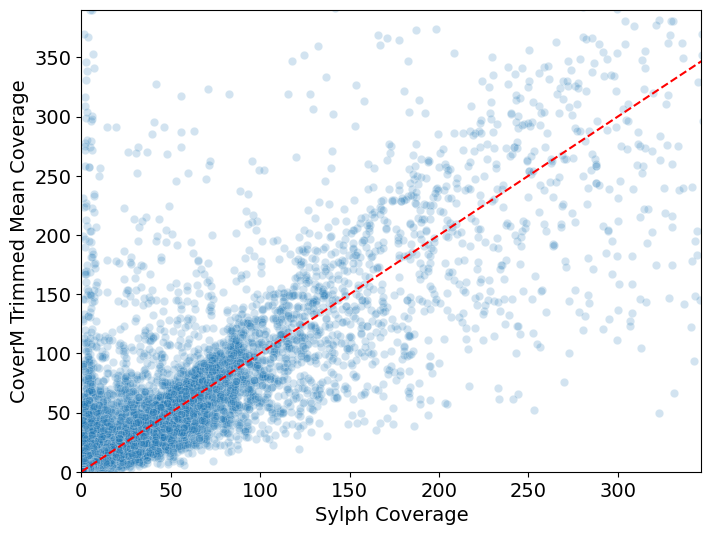

In [11]:
### Plot CoverM coverage vs sylph coverage
print("Number of CF metagenomes with CoverM UHVDB species: ", coverm.filter(pl.col('breadth_ratio') >= 0.6)['sample_id'].n_unique())
print("Number of detected UHVDB species: ", coverm.filter(pl.col('breadth_ratio') >= 0.6)['contig_id'].n_unique())


sylph_v_coverm_hq = (
    sylph_tax
        .select(['sample_id', 'clade_name', 'coverage', 'taxonomic_abundance', 'virus_host'])
        .with_columns(pl.col('clade_name').str.split('t__').list[-1].alias('contig_id'))
        .join(coverm.select(['contig_id', 'sample_id', 'trimmed_mean', 'mean', 'breadth_ratio']), on=['sample_id', 'contig_id'], how='full')
        .filter(pl.col('breadth_ratio') >= 0.6)
)

# calculate R-squared between sylph coverage and coverm trimmed mean
sylph_v_coverm_hq = sylph_v_coverm_hq.filter(pl.col('coverage').is_not_null() & pl.col('trimmed_mean').is_not_null())
correlation = sylph_v_coverm_hq.select(pl.corr('coverage', 'trimmed_mean')).item()
r_squared = correlation ** 2
print("R-squared between Sylph coverage and CoverM trimmed mean: ", r_squared)
print("Proportion of incongruities (> 2x difference):",
    sylph_v_coverm_hq
        .with_columns((pl.col('trimmed_mean') / pl.col('coverage')).alias('coverm_sylph_ratio'))
        .filter((pl.col('coverm_sylph_ratio') > 2) | (pl.col('coverm_sylph_ratio') < 0.5))
        .height / sylph_v_coverm_hq.height
)
print("Proportion of incongruities (> 5x difference):",
    sylph_v_coverm_hq
        .with_columns((pl.col('trimmed_mean') / pl.col('coverage')).alias('coverm_sylph_ratio'))
        .filter((pl.col('coverm_sylph_ratio') > 5) | (pl.col('coverm_sylph_ratio') < 0.2))
        .height / sylph_v_coverm_hq.height
)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=sylph_v_coverm_hq, x='coverage', y='trimmed_mean', alpha=0.2)
plt.xlabel('Sylph Coverage')
plt.ylabel('CoverM Trimmed Mean Coverage')
plt.xlim(0, sylph_v_coverm_hq['coverage'].quantile(0.99))
plt.ylim(0, sylph_v_coverm_hq['trimmed_mean'].quantile(0.99))
# add a y=x line for reference
max_val = max(sylph_v_coverm_hq['coverage'].quantile(0.99), sylph_v_coverm_hq['trimmed_mean'].quantile(0.99))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')
plt.show()

Number of CF metagenomes with sylph UHVDB species:  1789
Minimum UHVDB species richness:  1
Median UHVDB species richness:  16.0
Mean UHVDB species richness:  30.827836780324205
Maximum UHVDB species richness:  229


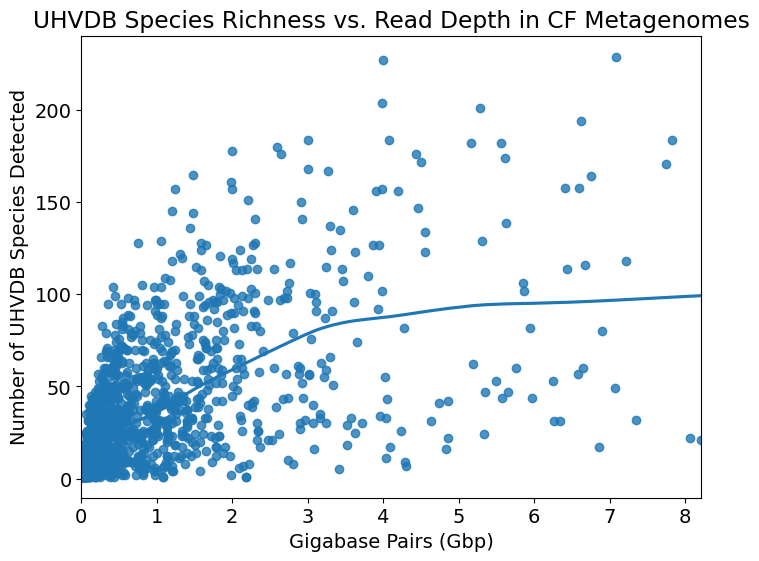

In [24]:
### Plot the number of UHVDB species detected by sylph by read depth
sylph_hq_species = sylph_v_coverm_hq.filter(pl.col('clade_name').str.contains(r'vSPECIES-.*\|t__'))
print("Number of CF metagenomes with sylph UHVDB species: ", sylph_v_coverm_hq['sample_id'].n_unique())

sylph_hq_species_richness = (
    sylph_v_coverm_hq
        .group_by('sample_id')
        .agg(pl.col('clade_name').n_unique().alias('species_richness'))
        .join(read_depth_plot, on='sample_id')
)
print("Minimum UHVDB species richness: ", sylph_hq_species_richness['species_richness'].min())
print("Median UHVDB species richness: ", sylph_hq_species_richness['species_richness'].median())
print("Mean UHVDB species richness: ", sylph_hq_species_richness['species_richness'].mean())
print("Maximum UHVDB species richness: ", sylph_hq_species_richness['species_richness'].max())

plt.figure(figsize=(8, 6))
sns.regplot(data=sylph_hq_species_richness, x='read_depth_gbp', y='species_richness', lowess=True)
plt.xlabel('Gigabase Pairs (Gbp)')
plt.ylabel('Number of UHVDB Species Detected')
plt.title('UHVDB Species Richness vs. Read Depth in CF Metagenomes')
plt.xlim(0, sylph_hq_species_richness['read_depth_gbp'].quantile(0.99))
plt.show()

In [25]:
### Identify assembled viruses aligning to UHVDB species
# count number of assembled viruses
with gzip.open('cf_metag_results/2026-04-08_outputs/classify/new_mq_plus_classify_2.fna.gz', 'rt') as fasta_file:
    cf_metag_viruses = set(
        line.split()[0][1:] for line in fasta_file if line.startswith('>')
    )
print("Number of assembled viruses: ", len(cf_metag_viruses))
classify_viruses = classify.filter(pl.col('seq_name').is_in(cf_metag_viruses))

# load assembly alignments to sylph hits per sample
vclust_sample_lst = []

for sample in list(set(coverm['sample_id'])):
    df = vclust.filter(pl.col('query').str.contains(sample))
    uhvdb_hits_in_sample = set(coverm.filter((pl.col('sample_id') == sample) & (pl.col('breadth_ratio') >= 0.6))['contig_id'])
    vclust_sample_lst.append(
        df.filter(pl.col('reference').is_in(uhvdb_hits_in_sample))
            .sort('gani', descending=True)
            .unique('query', maintain_order=True)
            .with_columns([pl.lit(sample).alias('sample_id')])
            .filter(pl.col('gani') >= 0.0)
    )
vclust_per_sample = pl.concat(vclust_sample_lst)
print("Number of assembled viruses with UHVDB hits: ", vclust_per_sample['query'].n_unique())

Number of assembled viruses:  8413
Number of assembled viruses with UHVDB hits:  7529


In [26]:
### Identify the taxonomy of assembled viruses not aligning to UHVDB species
classify_viruses.filter(~pl.col('seq_name').is_in(set(vclust_per_sample['query']))).group_by('taxonomy').len().sort('len', descending=True)

taxonomy,len
str,u32
"""Viruses;Duplodnaviria;Heunggon…",775
"""Viruses;Monodnaviria;Loebvirae…",76
"""Viruses;Duplodnaviria;Heunggon…",15
"""Viruses;;;;;;Anelloviridae""",5
"""Viruses;Duplodnaviria;Heunggon…",5
…,…
"""Viruses;Varidnaviria;Bamfordvi…",2
"""Viruses;Duplodnaviria;Heunggon…",1
"""Viruses;Duplodnaviria;Heunggon…",1


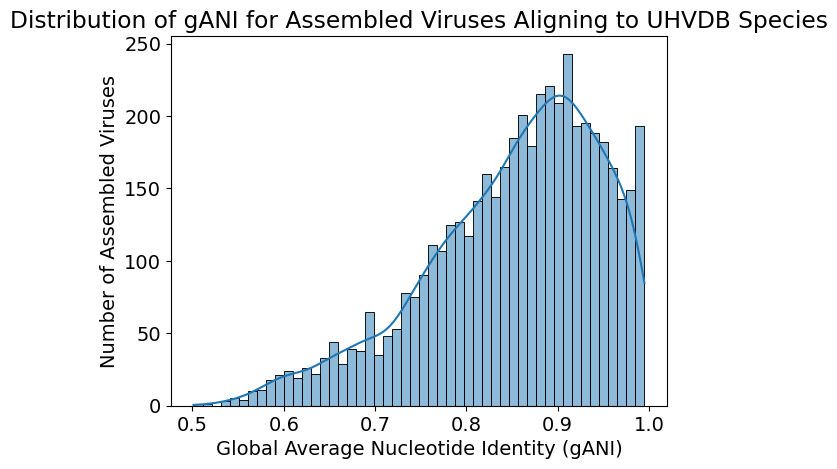

In [27]:
### Plot distribution of ANI for assembled viruses aligning to UHVDB species (EXCLUDING SELF HITS)
sns.histplot(vclust_per_sample.filter(pl.col('gani') < 0.995)['gani'], bins=50, kde=True)
plt.xlabel('Global Average Nucleotide Identity (gANI)')
plt.ylabel('Number of Assembled Viruses')
plt.title('Distribution of gANI for Assembled Viruses Aligning to UHVDB Species')
plt.show()

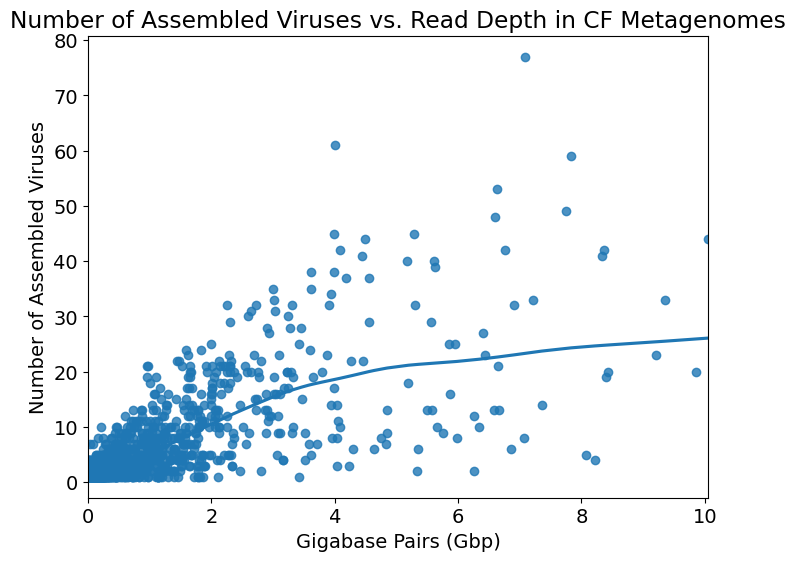

In [28]:
### Plot number of assembled viruses by read depth
assembled_viruses_per_sample = (
    vclust_per_sample
    .join(read_depth_plot, on='sample_id', how='left')
    .group_by('sample_id', 'read_depth_gbp')
    .agg(pl.col('query').n_unique().alias('num_assembled_viruses'))
)

plt.figure(figsize=(8, 6))
sns.regplot(data=assembled_viruses_per_sample, x='read_depth_gbp', y='num_assembled_viruses', lowess=True)
plt.xlabel('Gigabase Pairs (Gbp)')
plt.ylabel('Number of Assembled Viruses')
plt.title('Number of Assembled Viruses vs. Read Depth in CF Metagenomes')
plt.xlim(0, assembled_viruses_per_sample['read_depth_gbp'].quantile(0.99))
plt.show()

Number of samples with TR viruses:  432


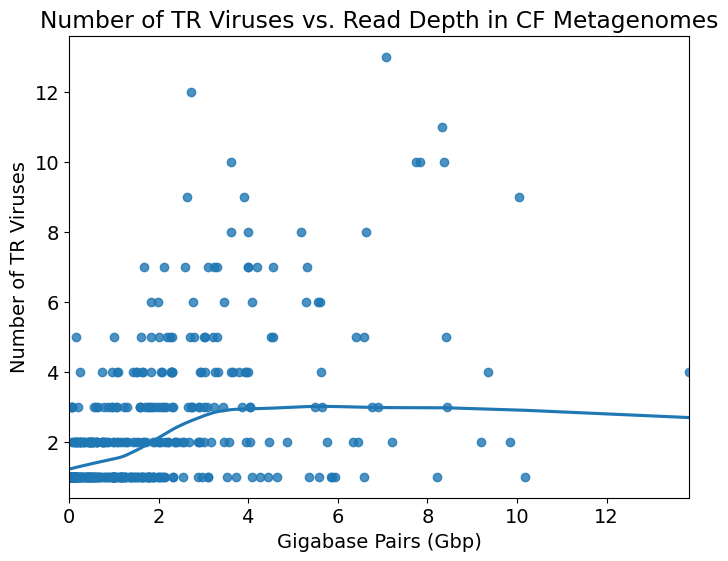

In [29]:
### Plot number of TR viruses by read depth
tr_viruses_by_read_depth = (
    classify_viruses
        .with_columns([pl.col('seq_name').str.split('_k').list[0].alias('sample_id')])
        .filter((pl.col('topology').str.contains('TR')) | (pl.col('completeness_method').str.contains('TR')))
        .group_by('sample_id')
        .agg(pl.len().alias('num_tr_viruses'))
        .join(read_depth_plot, on='sample_id', how='left')
)

print("Number of samples with TR viruses: ", tr_viruses_by_read_depth.filter(pl.col('num_tr_viruses') > 0).shape[0])
plt.figure(figsize=(8, 6))
sns.regplot(data=tr_viruses_by_read_depth, x='read_depth_gbp', y='num_tr_viruses', lowess=True)
plt.xlabel('Gigabase Pairs (Gbp)')
plt.ylabel('Number of TR Viruses')
plt.title('Number of TR Viruses vs. Read Depth in CF Metagenomes')
plt.xlim(0, tr_viruses_by_read_depth['read_depth_gbp'].quantile(0.99))
plt.show()

In [30]:
print("Number of mvirs circular: ",
    mvirs
        .with_columns(pl.col('mvirs_id').str.split('SF=').list[-1].cast(pl.Float64).alias('align_faction'))
        .filter(pl.col('align_faction') >= 99)
        .height
)
print("Number of mvirs prophages: ",
    mvirs
        .with_columns(pl.col('mvirs_id').str.split('SF=').list[-1].cast(pl.Float64).alias('align_faction'))
        .filter(pl.col('align_faction') < 99)
        .height
)

Number of mvirs circular:  145
Number of mvirs prophages:  891


Number of samples with mVIRs viruses:  386


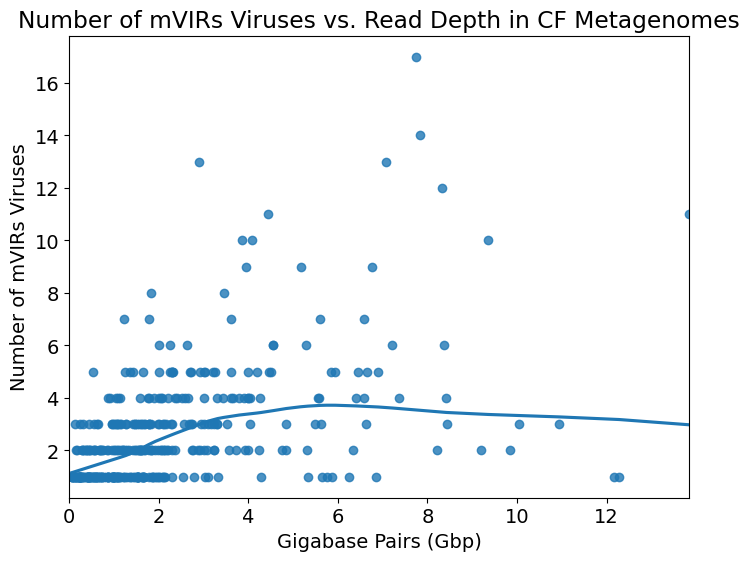

In [31]:
### Plot number of mVIRs viruses by read depth
mvirs_by_read_depth = (
    mvirs
        .group_by('sample_id')
        .agg(pl.len().alias('num_mvirs_viruses'))
        .join(read_depth_plot, on='sample_id', how='left')
)

print("Number of samples with mVIRs viruses: ", mvirs_by_read_depth.filter(pl.col('num_mvirs_viruses') > 0).shape[0])
plt.figure(figsize=(8, 6))
sns.regplot(data=mvirs_by_read_depth, x='read_depth_gbp', y='num_mvirs_viruses', lowess=True)
plt.xlabel('Gigabase Pairs (Gbp)')
plt.ylabel('Number of mVIRs Viruses')
plt.title('Number of mVIRs Viruses vs. Read Depth in CF Metagenomes')
plt.xlim(0, mvirs_by_read_depth['read_depth_gbp'].quantile(0.99))
plt.show()

Number of samples with propagate viruses:  318


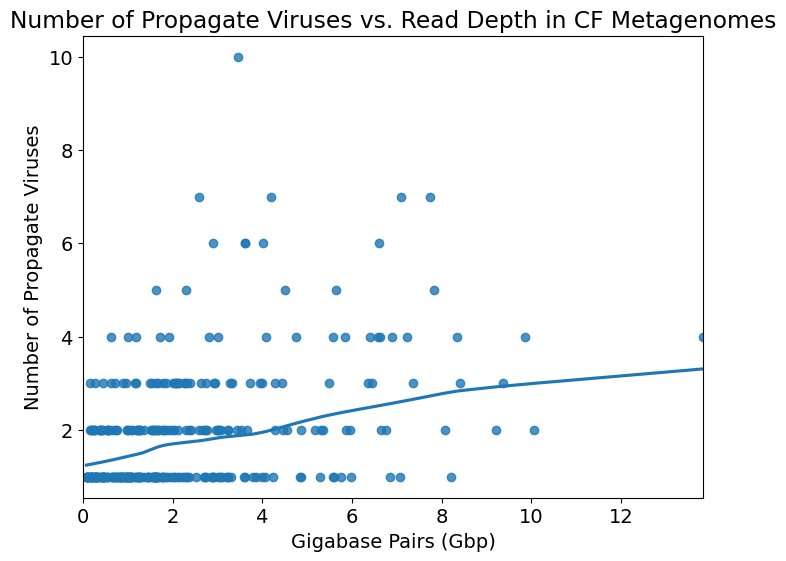

In [32]:
### Plot number of propagate viruses by read depth
propagate_by_read_depth = (
    propagate
        .filter((pl.col('CohenD') >= 0.7) & (pl.col('prophage-host_ratio') >= 1.25))
        .group_by('sample_id')
        .agg(pl.len().alias('num_propagate_viruses'))
        .join(read_depth_plot, on='sample_id', how='left')
)
print("Number of samples with propagate viruses: ", propagate_by_read_depth.filter(pl.col('num_propagate_viruses') > 0).shape[0])
plt.figure(figsize=(8, 6))
sns.regplot(data=propagate_by_read_depth, x='read_depth_gbp', y='num_propagate_viruses', lowess=True)
plt.xlabel('Gigabase Pairs (Gbp)')
plt.ylabel('Number of Propagate Viruses')
plt.title('Number of Propagate Viruses vs. Read Depth in CF Metagenomes')
plt.xlim(0, propagate_by_read_depth['read_depth_gbp'].quantile(0.99))
plt.show()

In [33]:
### Identify sylph UHVDB species with host
print("Total sylph species:", sylph_v_coverm_hq.height)
print("Number of sylph species with host species: ", sylph_v_coverm_hq.filter(pl.col('virus_host').str.contains('s__')).height)
print("Number of sylph species with host genus: ", sylph_v_coverm_hq.filter(pl.col('virus_host').str.contains('g__')).height)
print("Number of sylph species with host family: ", sylph_v_coverm_hq.filter(pl.col('virus_host').is_not_null()).height)

Total sylph species: 55151
Number of sylph species with host species:  26068
Number of sylph species with host genus:  50436
Number of sylph species with host family:  51809


In [34]:
### Identify most prevalent ictv classes
(
    sylph_v_coverm_hq
        .with_columns([
            pl.col('clade_name').str.split('viricota|').list[-1].str.split('|UNKNOWN').list[0].alias('ictv_class')
        ])
        .group_by('ictv_class')
        .len()
        .sort('len', descending=True)
        .head(10)
)

ictv_class,len
str,u32
"""Caudoviricetes""",48514
"""Faserviricetes""",4729
"""Arfiviricetes""",796
"""Malgrandaviricetes""",517
"""Revtraviricetes""",120
"""Howeltoviricetes""",114
"""Pisoniviricetes""",107
"""Tectiliviricetes""",82
"""Viruses""",56


In [35]:
### Identify most prevalent bacterial species
(
    sylph_tax
        .filter(pl.col('clade_name').str.contains(r'd__Bacteria.*s__'))
        .filter(~pl.col('clade_name').str.contains(r't__'))
        .with_columns(pl.col('clade_name').str.split('s__').list[-1].alias('clade_name'))
        .group_by('clade_name')
        .agg(pl.col('sample_id').n_unique().alias('num_samples'))
        .sort('num_samples', descending=True)
        .head(10)
)

clade_name,num_samples
str,u32
"""Prevotella melaninogenica""",885
"""Veillonella atypica""",871
"""Rothia mucilaginosa""",754
"""Veillonella nakazawae""",740
"""Porphyromonas pasteri""",703
"""Rothia dentocariosa""",622
"""Granulicatella sp015264885""",577
"""Streptococcus salivarius""",577
"""Prevotella pallens""",570


In [36]:
### Identify most prevalent bacterial species with known CF relevance
(
    sylph_tax
        .filter(pl.col('clade_name').str.contains(r'd__Bacteria.*s__'))
        .filter(~pl.col('clade_name').str.contains(r't__'))
        .filter(
            (pl.col('clade_name').str.contains('s__Pseudomonas aeruginosa')) |
            (pl.col('clade_name').str.contains('s__Stenotrophomonas maltophilia')) |
            (pl.col('clade_name').str.contains('s__Achromobacter xylosoxidans')) |
            (pl.col('clade_name').str.contains('s__Burkholderia')) |
            (pl.col('clade_name').str.contains('s__Staphylococcus aureus')) |
            (pl.col('clade_name').str.contains('s__Haemophilus influenzae'))
        )
        .with_columns(pl.col('clade_name').str.split('s__').list[-1].alias('clade_name'))
        .group_by('clade_name')
        .agg(pl.col('sample_id').n_unique().alias('num_samples'))
        .sort('num_samples', descending=True)
        .head(10)
)

clade_name,num_samples
str,u32
"""Pseudomonas aeruginosa""",547
"""Staphylococcus aureus""",515
"""Haemophilus influenzae""",158
"""Stenotrophomonas maltophilia""",80
"""Haemophilus influenzae_E""",47
"""Haemophilus influenzae_D""",45
"""Achromobacter xylosoxidans""",32
"""Burkholderia multivorans""",23
"""Burkholderia contaminans""",22


In [56]:
# Constants for statistics
N_CO_OCCURRENCE_THRESHOLD = 5
N_SAMPLES = sylph_v_coverm_hq.select("sample_id").n_unique()
N_PERMUTATIONS = 100 # Increase to 20-50 for an even denser null distribution

In [39]:
import polars as pl
import numpy as np
from scipy.stats import fisher_exact
import random

# ==========================================
# 1. INITIAL DF PREPROCESSING
# ==========================================
# Note: Ensure your input 'sylph_tax' has a 'sample_id' column
# (Assuming N_SAMPLES, N_PERMUTATIONS, N_CO_OCCURRENCE_THRESHOLD are defined globally)

virus_df = (
    sylph_v_coverm_hq
    .filter(pl.col('virus_host').str.contains('s__'))
    .with_columns([pl.col('virus_host').str.replace_all(';', '|')])
    .rename({'clade_name': 'virus_species', 'taxonomic_abundance': 'virus_taxonomic_abundance'})
)

bac_df = (
    sylph_tax
    .filter(pl.col('clade_name').str.starts_with('d__Bacteria'))
    .filter(pl.col('clade_name').str.contains('s__'))
    .filter(~pl.col('clade_name').str.contains('t__'))
    .with_columns([pl.col('clade_name').str.replace_all(';', '|')]) # Standardize separator
    .rename({'clade_name': 'bac_species', 'taxonomic_abundance': 'bac_taxonomic_abundance'})
)

# Constants for statistics
BACTERIAL_POOL = bac_df.select("bac_species").unique().to_series().to_list()

# ==========================================
# 2. GENERATE TRUE & NULL MAPPINGS (PERMUTED)
# ==========================================
def get_random_host(true_host):
    choice = random.choice(BACTERIAL_POOL)
    while choice == true_host:
        choice = random.choice(BACTERIAL_POOL)
    return choice

# The True Mapping
true_mapping = virus_df.select(["virus_species", "virus_host"]).unique()

# Generate Multiple Null Mappings
null_mapping_list = []
for i in range(N_PERMUTATIONS):
    iter_mapping = (
        true_mapping
        .with_columns([
            pl.col("virus_host").map_elements(get_random_host, return_dtype=pl.String).alias("null_host"),
            pl.lit(f"Null_{i}").alias("iteration")
        ])
        .select(["virus_species", "null_host", "iteration"])
    )
    null_mapping_list.append(iter_mapping)

# Combine all permutations into one master null mapping table
null_mapping_expanded = pl.concat(null_mapping_list)

# Get total prevalence for Fisher calculation
v_prev = virus_df.group_by("virus_species").agg(pl.len().alias("v_total_count"))
b_prev = bac_df.group_by("bac_species").agg(pl.len().alias("b_total_count"))

# ==========================================
# 3. CORE ANALYSIS FUNCTION
# ==========================================
def run_association_pipeline(v_df, b_df, mapping_table, host_col_name, label, is_null=False):
    """
    Performs Fisher's, Spearman, and calculates Phage-to-Host Ratios on a specified host column.
    Dynamically adjusts grouping to account for permutations if is_null=True.
    """
    group_cols = ["virus_species", host_col_name]
    if is_null:
        group_cols.append("iteration")

    # Join to find co-occurrences
    co_occurrences = (
        v_df.select(["sample_id", "virus_species"])
        .join(mapping_table, on="virus_species")
        .join(
            b_df.select(["sample_id", "bac_species"]),
            left_on=["sample_id", host_col_name],
            right_on=["sample_id", "bac_species"],
            how="inner"
        )
        .group_by(group_cols)
        .agg(pl.len().alias("n11"))
    )

    # Build Fisher Table
    fisher_table = (
        co_occurrences
        .join(v_prev, on="virus_species")
        .join(b_prev, left_on=host_col_name, right_on="bac_species")
        .with_columns([
            (pl.col("v_total_count") - pl.col("n11")).alias("n10"),
            (pl.col("b_total_count") - pl.col("n11")).alias("n01"),
            (N_SAMPLES - pl.col("v_total_count") - pl.col("b_total_count") + pl.col("n11")).alias("n00")
        ])
    )

    # Apply Fisher's Exact
    def fast_fisher(row):
        odds_ratio, p_value = fisher_exact([[row[0], row[1]], [row[2], row[3]]], alternative='greater')
        return {"odds_ratio": float(odds_ratio), "p_value": float(p_value)}

    # Filter by co-occurrence threshold
    stats_base = (
        fisher_table.filter(pl.col("n11") >= N_CO_OCCURRENCE_THRESHOLD)
        .with_columns(
            pl.struct(["n11", "n10", "n01", "n00"])
            .map_elements(
                lambda r: fast_fisher([r["n11"], r["n10"], r["n01"], r["n00"]]), 
                return_dtype=pl.Struct({"odds_ratio": pl.Float64, "p_value": pl.Float64})
            )
            .alias("fisher_stats")
        )
        .unnest("fisher_stats")
    )

    # Calculate Spearman and Virus-to-Host Ratios (VHR)
    joint_abundances = (
        v_df.select(["sample_id", "virus_species", "virus_taxonomic_abundance"])
        .join(stats_base.select(group_cols), on="virus_species")
        .join(
            b_df.select(["sample_id", "bac_species", "bac_taxonomic_abundance"]),
            left_on=["sample_id", host_col_name],
            right_on=["sample_id", "bac_species"]
        )
        # --- NEW: Calculate the ratio per sample ---
        .with_columns(
            (pl.col("virus_taxonomic_abundance") / pl.col("bac_taxonomic_abundance")).alias("sample_vhr")
        )
    )

    # --- NEW: Aggregate Spearman, Median VHR, and Max VHR ---
    abundance_stats = (
        joint_abundances
        .group_by(group_cols)
        .agg([
            pl.corr("virus_taxonomic_abundance", "bac_taxonomic_abundance", method="spearman").alias("rho"),
            pl.col("sample_vhr").mean().alias("mean_vhr"),
            pl.col('sample_vhr').std().alias('std_vhr'),
            pl.col("sample_vhr").median().alias("median_vhr"),
            pl.col("sample_vhr").max().alias("max_vhr")
        ])
    )

    # Standardize output format 
    final_output = (
        stats_base
        .join(abundance_stats, on=group_cols)
        .with_columns(pl.lit(label).alias("type"))
        # --- NEW: Added median_vhr and max_vhr to final selection ---
        .select(["virus_species", host_col_name, "n11", "odds_ratio", "p_value", "rho", 'mean_vhr', 'std_vhr', "median_vhr", "max_vhr", "type"])
    )
    
    return final_output.rename({host_col_name: "host_name"}), joint_abundances

# ==========================================
# 4. EXECUTION
# ==========================================
# Run True
true_results, true_pair_abundances = run_association_pipeline(
    virus_df, bac_df, true_mapping, "virus_host", "True Pair", is_null=False
)

# Run Null (Permuted)
null_results, null_pair_abundances = run_association_pipeline(
    virus_df, bac_df, null_mapping_expanded, "null_host", "Null Model", is_null=True
)

# Combine for plotting
final_plot_df = pl.concat([true_results, null_results])

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 5. PLOT DATA PREPARATION
# ==========================================

# Combine the two dataframes
plot_df = (
    final_plot_df
    .with_columns([
        # Calculate -log10 p-value; add a tiny epsilon to avoid log(0)
        (pl.col("p_value") + 1e-15).log10().mul(-1).alias("neg_log_p")
    ])
    .to_pandas() # Seaborn works best with Pandas
)

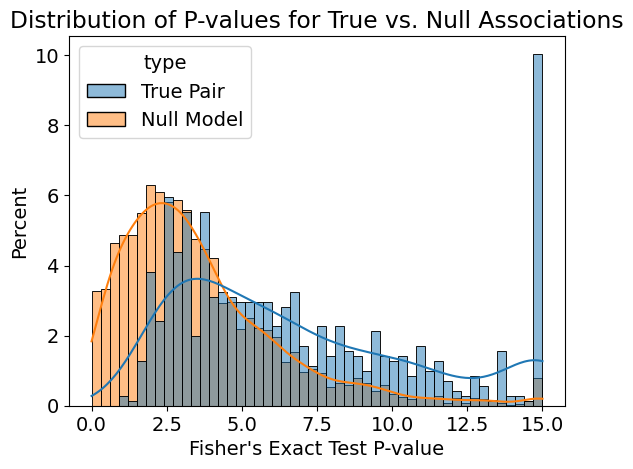

In [41]:
sns.histplot(plot_df, x="neg_log_p", hue="type", bins=50, kde=True, stat="percent", common_norm=False)
plt.xlabel("Fisher's Exact Test P-value")
plt.title("Distribution of P-values for True vs. Null Associations")
plt.show()

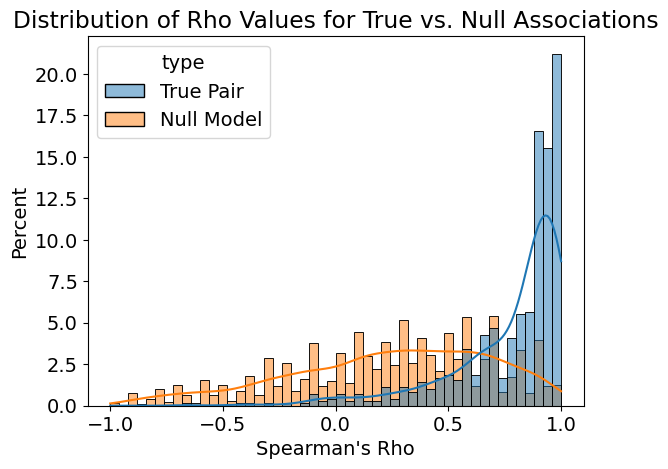

In [42]:
sns.histplot(plot_df, x="rho", hue="type", bins=50, kde=True, stat="percent", common_norm=False)
plt.xlabel("Spearman's Rho")
plt.title("Distribution of Rho Values for True vs. Null Associations")
plt.show()

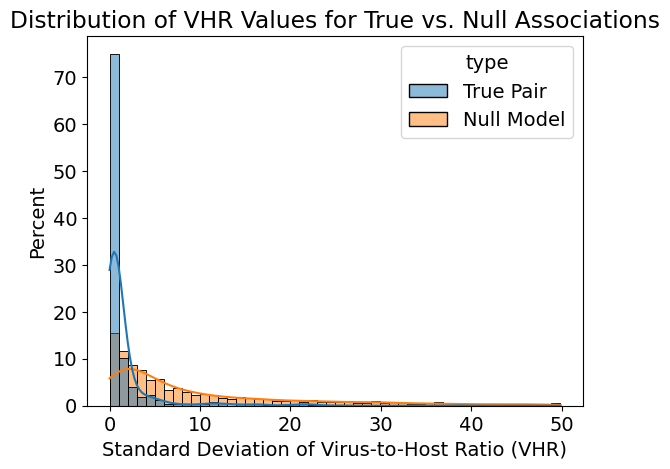

In [43]:
vhr_filt = pl.from_pandas(plot_df).filter(pl.col('std_vhr') <= 50)
sns.histplot(vhr_filt, x="std_vhr", hue="type", bins=50, kde=True, stat="percent", common_norm=False)
plt.xlabel("Standard Deviation of Virus-to-Host Ratio (VHR)")
plt.title("Distribution of VHR Values for True vs. Null Associations")
plt.show()

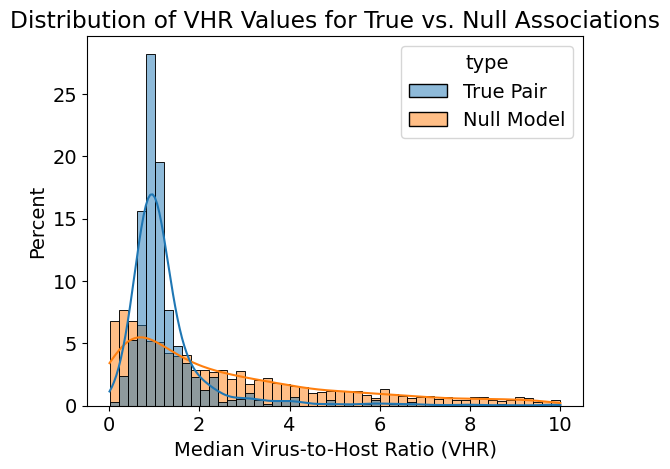

In [44]:
vhr_filt = pl.from_pandas(plot_df).filter(pl.col('median_vhr') <= 10)
sns.histplot(vhr_filt, x="median_vhr", hue="type", bins=50, kde=True, stat="percent", common_norm=False)
plt.xlabel("Median Virus-to-Host Ratio (VHR)")
plt.title("Distribution of VHR Values for True vs. Null Associations")
plt.show()

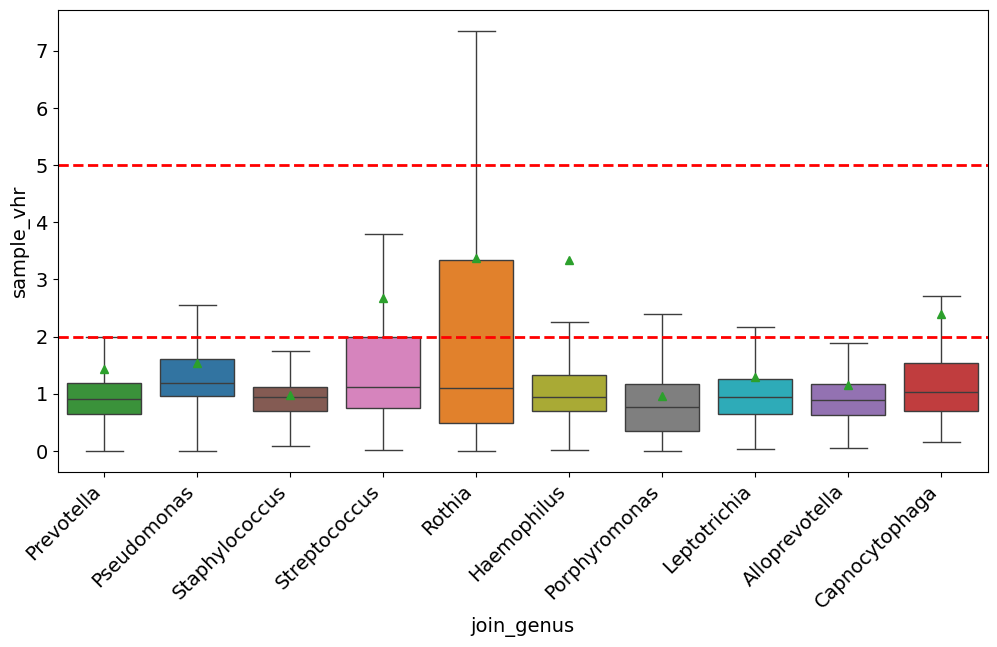

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

# Extract ICTV class
true_pair_abundances = (
    true_pair_abundances
    .with_columns(
        pl.col('virus_species').str.extract(r"\|([A-Za-z]+viricetes)", 1).alias('ictv_class'),
        pl.col('virus_host').str.extract(r"\|g__([A-Za-z]+)", 1).alias('join_genus'),
    )
)

# 1. Convert to Pandas for Seaborn categorical stability
df_pd = true_pair_abundances.to_pandas()

# 2. Keep only the 10 most prevalent genera (by number of detections)
top10_genera = df_pd['join_genus'].value_counts(dropna=True).head(10).index.tolist()
df_pd = df_pd[df_pd['join_genus'].isin(top10_genera)].copy()

# Use prevalence order for consistent plotting
genus_order = df_pd['join_genus'].value_counts().index.tolist()

plt.figure(figsize=(12, 6))

# 3. Base Boxplot
ax = sns.boxplot(
    data=df_pd, 
    x='join_genus', 
    y='sample_vhr', 
    hue='join_genus', 
    order=genus_order,
    showmeans=True, 
    showfliers=False
 )


# 5. Add horizontal threshold lines
plt.axhline(y=5, color='red', linestyle='--', linewidth=2, label='Threshold 5')
plt.axhline(y=2, color='red', linestyle='--', linewidth=2, label='Threshold 2')

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

# plt.tight_layout()
plt.show()

In [48]:
import polars as pl
from scipy.stats import fisher_exact

# ==========================================
# 0. STRICT TARGET PATHOGEN FILTERING
# ==========================================

# 1. Phage Predicted Host Pattern (Targeting the Genus level)
phage_host_pattern = r"(?i)g__(Pseudomonas|Staphylococcus|Stenotrophomonas|Burkholderia|Haemophilus|Achromobacter)\b"

# 2. Bacterial Taxa Pattern (Targeting specific Species, plus Burkholderia/Achromobacter genus)
bac_target_pattern = r"(?i)(s__Pseudomonas aeruginosa\b|s__Staphylococcus aureus\b|s__Stenotrophomonas maltophilia\b|g__Burkholderia\b|g__Achromobacter\b|s__Haemophilus influenzae\b)"

# Filter the dataframes using the strict markers
target_virus_df = virus_df.filter(pl.col("virus_host").str.contains(phage_host_pattern))
target_bac_df = bac_df.filter(pl.col("bac_species").str.contains(bac_target_pattern))

print(f"Targeted Phages: {target_virus_df.select('virus_species').n_unique()}")
print(f"Targeted Bacteria: {target_bac_df.select('bac_species').n_unique()}")

# ==========================================
# 1. PREPARE CANDIDATE PAIRS (Co-occurrence >= 5)
# ==========================================

# --- NEW: Extract the common 'Genus' to use as a strict join key ---
# This looks for 'g__Name' and pulls just 'Name' out into a new column
target_virus_prepared = target_virus_df.with_columns(
    pl.col("virus_host").str.extract(r"g__([A-Za-z]+)", 1).alias("join_genus")
)

target_bac_prepared = target_bac_df.with_columns(
    pl.col("bac_species").str.extract(r"g__([A-Za-z]+)", 1).alias("join_genus")
)

# Step 1: Find every pair using the TARGETED dataframes AND the Genus Key
co_occurrence_counts = (
    target_virus_prepared.select(["sample_id", "virus_species", "join_genus"])
    .join(
        target_bac_prepared.select(["sample_id", "bac_species", "join_genus"]),
        on=["sample_id", "join_genus"], # <-- MODIFIED: Now requires matching samples AND matching taxonomy
        how="inner"
    )
    # Step 2: Group by the pair and count unique samples (n11)
    .group_by(["virus_species", "bac_species", "join_genus"])
    .agg(pl.len().alias("n11"))
    # Step 3: Filter for co-occurrence threshold
    .filter(pl.col("n11") >= N_CO_OCCURRENCE_THRESHOLD)
)

# ==========================================
# 2. FISHER P-VALUE (All samples context)
# ==========================================

# NOTE: We still join against the GLOBAL v_prev and b_prev here
# to maintain accurate statistical absence context.
discovery_stats = (
    co_occurrence_counts
    .join(v_prev, on="virus_species")
    .join(b_prev, on="bac_species")
    .with_columns([
        (pl.col("v_total_count") - pl.col("n11")).alias("n10"),
        (pl.col("b_total_count") - pl.col("n11")).alias("n01"),
        (N_SAMPLES - pl.col("v_total_count") - pl.col("b_total_count") + pl.col("n11")).alias("n00")
    ])
)

def calculate_fisher_p(row):
    _, p_val = fisher_exact(
        [[row[0], row[1]], [row[2], row[3]]], 
        alternative='greater'
    )
    return float(p_val)

discovery_stats = discovery_stats.with_columns(
    pl.struct(["n11", "n10", "n01", "n00"])
    .map_elements(
        lambda r: calculate_fisher_p([r["n11"], r["n10"], r["n01"], r["n00"]]),
        return_dtype=pl.Float64
    )
    .alias("fisher_p_value")
)

# ==========================================
# 3. SPEARMAN RHO & VHR (Both-detected samples only)
# ==========================================

# Join abundances using the TARGETED dataframes for speed
pair_abundances = (
    discovery_stats.select(["virus_species", "bac_species", "join_genus"])
    .join(target_virus_df.select(["sample_id", "virus_species", "virus_taxonomic_abundance"]), on="virus_species")
    .join(
        target_bac_df.select(["sample_id", "bac_species", "bac_taxonomic_abundance"]),
        on=["sample_id", "bac_species"],
        how="inner" 
    )
    # --- NEW: Calculate the ratio per sample ---
    .with_columns(
        (pl.col("virus_taxonomic_abundance") / pl.col("bac_taxonomic_abundance")).alias("sample_vhr")
    )
)

# --- MODIFIED: Aggregate Rho, Median VHR, and Max VHR ---
abundance_stats = (
    pair_abundances
    .group_by(["virus_species", "bac_species", "join_genus"])
    .agg([
        pl.corr("virus_taxonomic_abundance", "bac_taxonomic_abundance", method="spearman").alias("spearman_rho"),
        pl.col('sample_vhr').mean().alias('mean_vhr'),
        pl.col('sample_vhr').std().alias('std_vhr'),
        pl.col("sample_vhr").median().alias("median_vhr"),
        pl.col("sample_vhr").max().alias("max_vhr")
    ])
)

# ==========================================
# 4. FINAL MERGE & ANNOTATION
# ==========================================

final_discovery_df = (
    discovery_stats
    .join(abundance_stats, on=["virus_species", "bac_species", "join_genus"]) 
    .select([
        "virus_species", 
        "bac_species",
        "join_genus",
        "n11", 
        "fisher_p_value", 
        "spearman_rho",
        "median_vhr", 
        "max_vhr",     
        "std_vhr"
    ])
    .with_columns([
        # Calculate -log10 p-value; add a tiny epsilon to avoid log(0)
        (pl.col("fisher_p_value") + 1e-15).log10().mul(-1).alias("neg_log_p")
    ])
)

Targeted Phages: 646
Targeted Bacteria: 22


In [49]:
# plot number of phages by host genus
(
    final_discovery_df
    .group_by("join_genus")
    .agg(pl.col("virus_species").n_unique().alias("num_phages"))
    .sort("num_phages", descending=True)
)

join_genus,num_phages
str,u32
"""Pseudomonas""",90
"""Staphylococcus""",66
"""Stenotrophomonas""",9
"""Haemophilus""",9
"""Burkholderia""",8
"""Achromobacter""",6


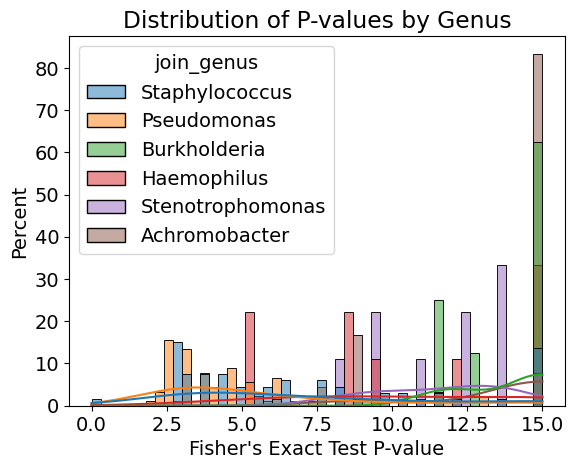

In [50]:
sns.histplot(final_discovery_df, x="neg_log_p", hue="join_genus", bins=50, kde=True, stat="percent", common_norm=False)
plt.xlabel("Fisher's Exact Test P-value")
plt.title("Distribution of P-values by Genus")
plt.show()

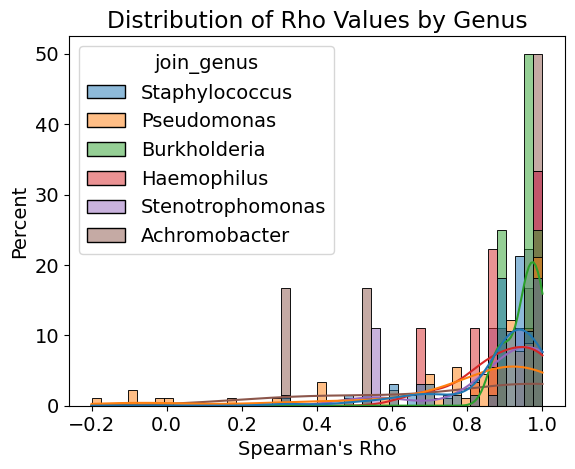

In [51]:
sns.histplot(final_discovery_df, x="spearman_rho", hue="join_genus", bins=50, kde=True, stat="percent", common_norm=False)
plt.xlabel("Spearman's Rho")
plt.title("Distribution of Rho Values by Genus")
plt.show()

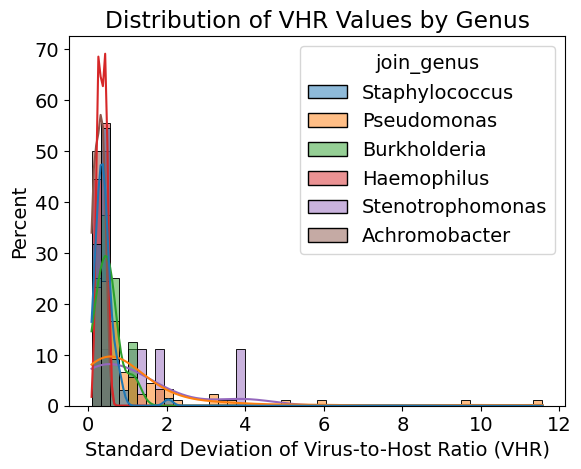

In [52]:
vhr_filt = final_discovery_df.filter(pl.col('std_vhr') <= 50)
sns.histplot(vhr_filt, x="std_vhr", hue="join_genus", bins=50, kde=True, stat="percent", common_norm=False)
plt.xlabel("Standard Deviation of Virus-to-Host Ratio (VHR)")
plt.title("Distribution of VHR Values by Genus")
plt.show()

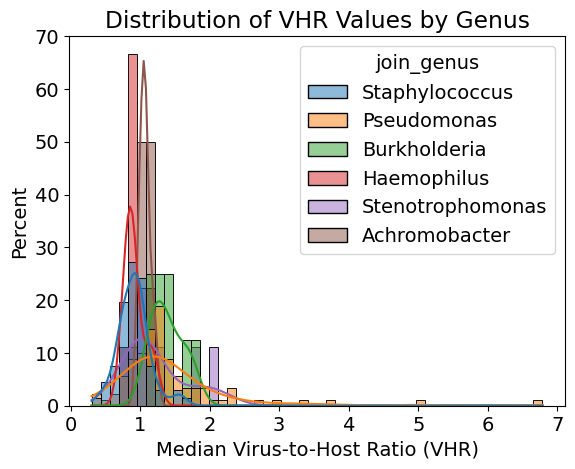

In [53]:
vhr_filt = final_discovery_df.filter(pl.col('median_vhr') <= 10)
sns.histplot(vhr_filt, x="median_vhr", hue="join_genus", bins=50, kde=True, stat="percent", common_norm=False)
plt.xlabel("Median Virus-to-Host Ratio (VHR)")
plt.title("Distribution of VHR Values by Genus")
plt.show()

In [54]:
### Number of samples with phage-host detection
pair_abundances.group_by('join_genus').len()

join_genus,len
str,u32
"""Pseudomonas""",1332
"""Achromobacter""",66
"""Staphylococcus""",1078
"""Burkholderia""",65
"""Haemophilus""",111
"""Stenotrophomonas""",76


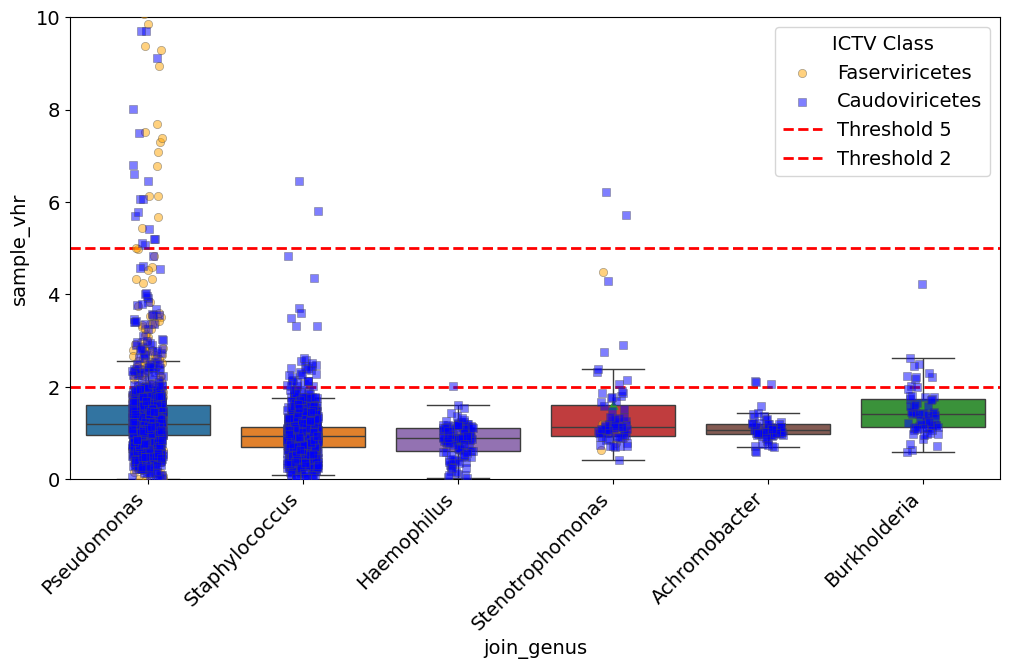

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

# Extract ICTV class
pair_abundances = pair_abundances.with_columns(
    pl.col('virus_species').str.extract(r"\|([A-Za-z]+viricetes)", 1).alias('ictv_class')
)

# 1. Convert to Pandas for Seaborn categorical stability
df_pd = pair_abundances.to_pandas()

# 2. Keep only the 10 most prevalent genera (by number of detections)
top10_genera = df_pd['join_genus'].value_counts(dropna=True).head(10).index.tolist()
df_pd = df_pd[df_pd['join_genus'].isin(top10_genera)].copy()

# Use prevalence order for consistent plotting
genus_order = df_pd['join_genus'].value_counts().index.tolist()

plt.figure(figsize=(12, 6))

# 3. Base Boxplot
ax = sns.boxplot(
    data=df_pd, 
    x='join_genus', 
    y='sample_vhr', 
    hue='join_genus', 
    order=genus_order,
    showmeans=True, 
    showfliers=False
 )

marker_styles = {"Caudoviricetes": "s", "Faserviricetes": "o"}
color_styles = {"Caudoviricetes": "blue", "Faserviricetes": "orange"}

# 4. Overlay points by ICTV class
for ictv_class in df_pd["ictv_class"].dropna().unique():
    subset = df_pd[df_pd["ictv_class"] == ictv_class]
    
    sns.stripplot(
        data=subset, 
        x="join_genus", 
        y="sample_vhr", 
        order=genus_order,
        color=color_styles.get(ictv_class, "black"),
        marker=marker_styles.get(ictv_class, "x"),
        jitter=True,
        alpha=0.5,
        size=6,
        linewidth=0.5,
        ax=ax,
        label=ictv_class
    )

plt.ylim(0, 10)

# 5. Add horizontal threshold lines
plt.axhline(y=5, color='red', linestyle='--', linewidth=2, label='Threshold 5')
plt.axhline(y=2, color='red', linestyle='--', linewidth=2, label='Threshold 2')

# 6. Smart Legend Deduplication
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="ICTV Class", loc="upper right")

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

plt.show()

In [58]:
vhr_cats = (
    pair_abundances
        .with_columns([
            pl.when(pl.col('sample_vhr') >= 5).then(pl.lit('High VHR')).when(pl.col('sample_vhr') >= 2).then(pl.lit('Moderate VHR')).otherwise(pl.lit('Low VHR')).alias('vhr_category')
        ])
)

(
    vhr_cats
        .group_by(['join_genus', 'vhr_category'])
        # calculate proportion of each VHR category within each genus
        .agg(pl.len().alias('count'))
        .with_columns([(pl.col('count') / pl.col('count').sum().over('join_genus')).alias('proportion')])
        .sort(['join_genus', 'proportion'], descending=[False, True])
        .filter(pl.col('vhr_category') != 'Low VHR')
)

join_genus,vhr_category,count,proportion
str,str,u32,f64
"""Achromobacter""","""Moderate VHR""",3,0.045455
"""Burkholderia""","""Moderate VHR""",10,0.153846
"""Haemophilus""","""Moderate VHR""",1,0.009009
"""Pseudomonas""","""Moderate VHR""",151,0.113363
"""Pseudomonas""","""High VHR""",39,0.029279
"""Staphylococcus""","""Moderate VHR""",35,0.032468
"""Staphylococcus""","""High VHR""",2,0.001855
"""Stenotrophomonas""","""Moderate VHR""",8,0.105263
"""Stenotrophomonas""","""High VHR""",3,0.039474


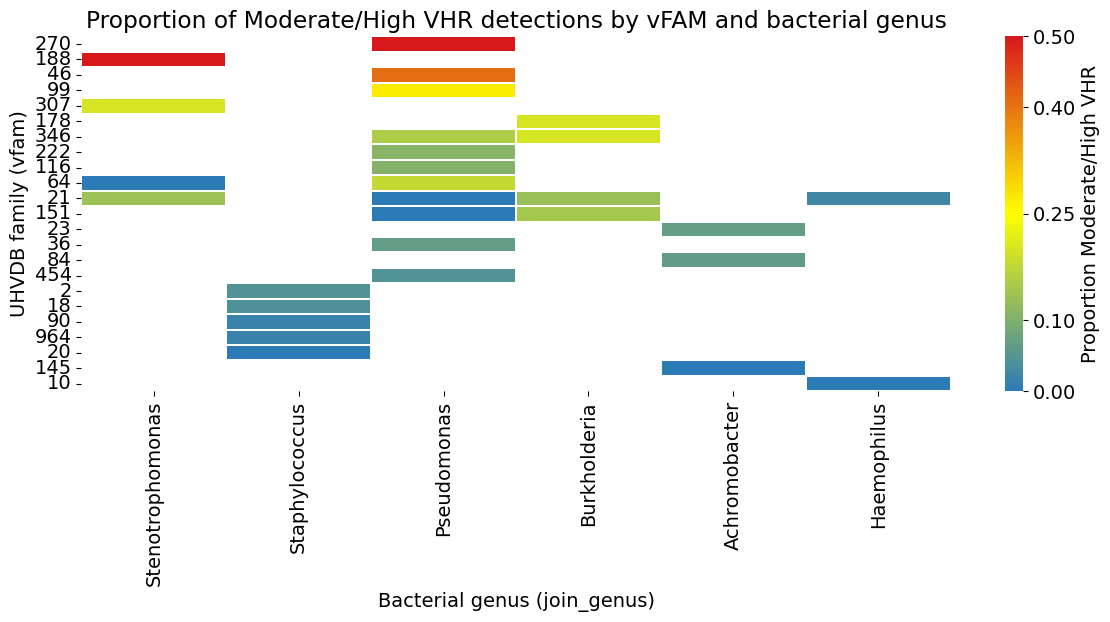

join_genus,vfam,ictv_class,n_detections_in_vfam,n_moderate_or_high_detections,proportion_moderate_or_high
str,str,str,u32,i64,f64
"""Pseudomonas""","""270""","""Faserviricetes""",51,33,0.647059
"""Stenotrophomonas""","""188""","""Caudoviricetes""",10,5,0.5
"""Pseudomonas""","""46""","""Caudoviricetes""",59,24,0.40678
"""Pseudomonas""","""99""","""Caudoviricetes""",59,16,0.271186
"""Burkholderia""","""178""","""Caudoviricetes""",10,2,0.2
…,…,…,…,…,…
"""Pseudomonas""","""21""","""Caudoviricetes""",73,0,0.0
"""Achromobacter""","""145""","""Caudoviricetes""",14,0,0.0
"""Pseudomonas""","""151""","""Caudoviricetes""",11,0,0.0


In [59]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

vfam_vhr_summary = (
    vhr_cats
        .with_columns([
            pl.col('virus_species').str.split('vFAM-').list[-1].str.split('|').list[0].alias('vfam'),
            pl.col('vhr_category').is_in(['Moderate VHR', 'High VHR']).alias('is_moderate_or_high')
        ])
        .group_by('join_genus', 'vfam', 'ictv_class')
        .agg([
            pl.len().alias('n_detections_in_vfam'),
            pl.col('is_moderate_or_high').cast(pl.Int64).sum().alias('n_moderate_or_high_detections')
        ])
        .with_columns([
            (pl.col('n_moderate_or_high_detections') / pl.col('n_detections_in_vfam')).alias('proportion_moderate_or_high')
        ])
        .sort('proportion_moderate_or_high', descending=True)
        .filter(pl.col('n_detections_in_vfam') >= 10)
 )

# Collapse across ictv_class so each join_genus-vfam pair has one value
vfam_heatmap_df = (
    vfam_vhr_summary
        .group_by(['join_genus', 'vfam'])
        .agg([
            pl.col('n_detections_in_vfam').sum().alias('n_detections_in_vfam'),
            pl.col('n_moderate_or_high_detections').sum().alias('n_moderate_or_high_detections')
        ])
        .with_columns([
            (pl.col('n_moderate_or_high_detections') / pl.col('n_detections_in_vfam')).alias('proportion_moderate_or_high')
        ])
 )

heatmap_pd = (
    vfam_heatmap_df
        .pivot(index='vfam', on='join_genus', values='proportion_moderate_or_high')
        .to_pandas()
        .set_index('vfam')
 )

# Optional ordering for readability
heatmap_pd = heatmap_pd.loc[heatmap_pd.mean(axis=1).sort_values(ascending=False).index]

# Emphasize 50% (0.5) with a bright midpoint-aware scale on [0, 0.5]
vhr_cmap = LinearSegmentedColormap.from_list(
    'vhr_emphasis',
    [(0.0, '#2c7bb6'), (0.5, '#ffff00'), (1.0, '#d7191c')]
 )
vhr_norm = TwoSlopeNorm(vmin=0.0, vcenter=0.25, vmax=0.5)

plt.figure(figsize=(12, max(6, 0.28 * heatmap_pd.shape[0])))
sns.heatmap(
    heatmap_pd,
    cmap=vhr_cmap,
    norm=vhr_norm,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Proportion Moderate/High VHR', 'ticks': [0.0, 0.1, 0.25, 0.4, 0.5]}
)
plt.title('Proportion of Moderate/High VHR detections by vFAM and bacterial genus')
plt.xlabel('Bacterial genus (join_genus)')
plt.ylabel('UHVDB family (vfam)')
plt.tight_layout()
plt.show()

vfam_vhr_summary

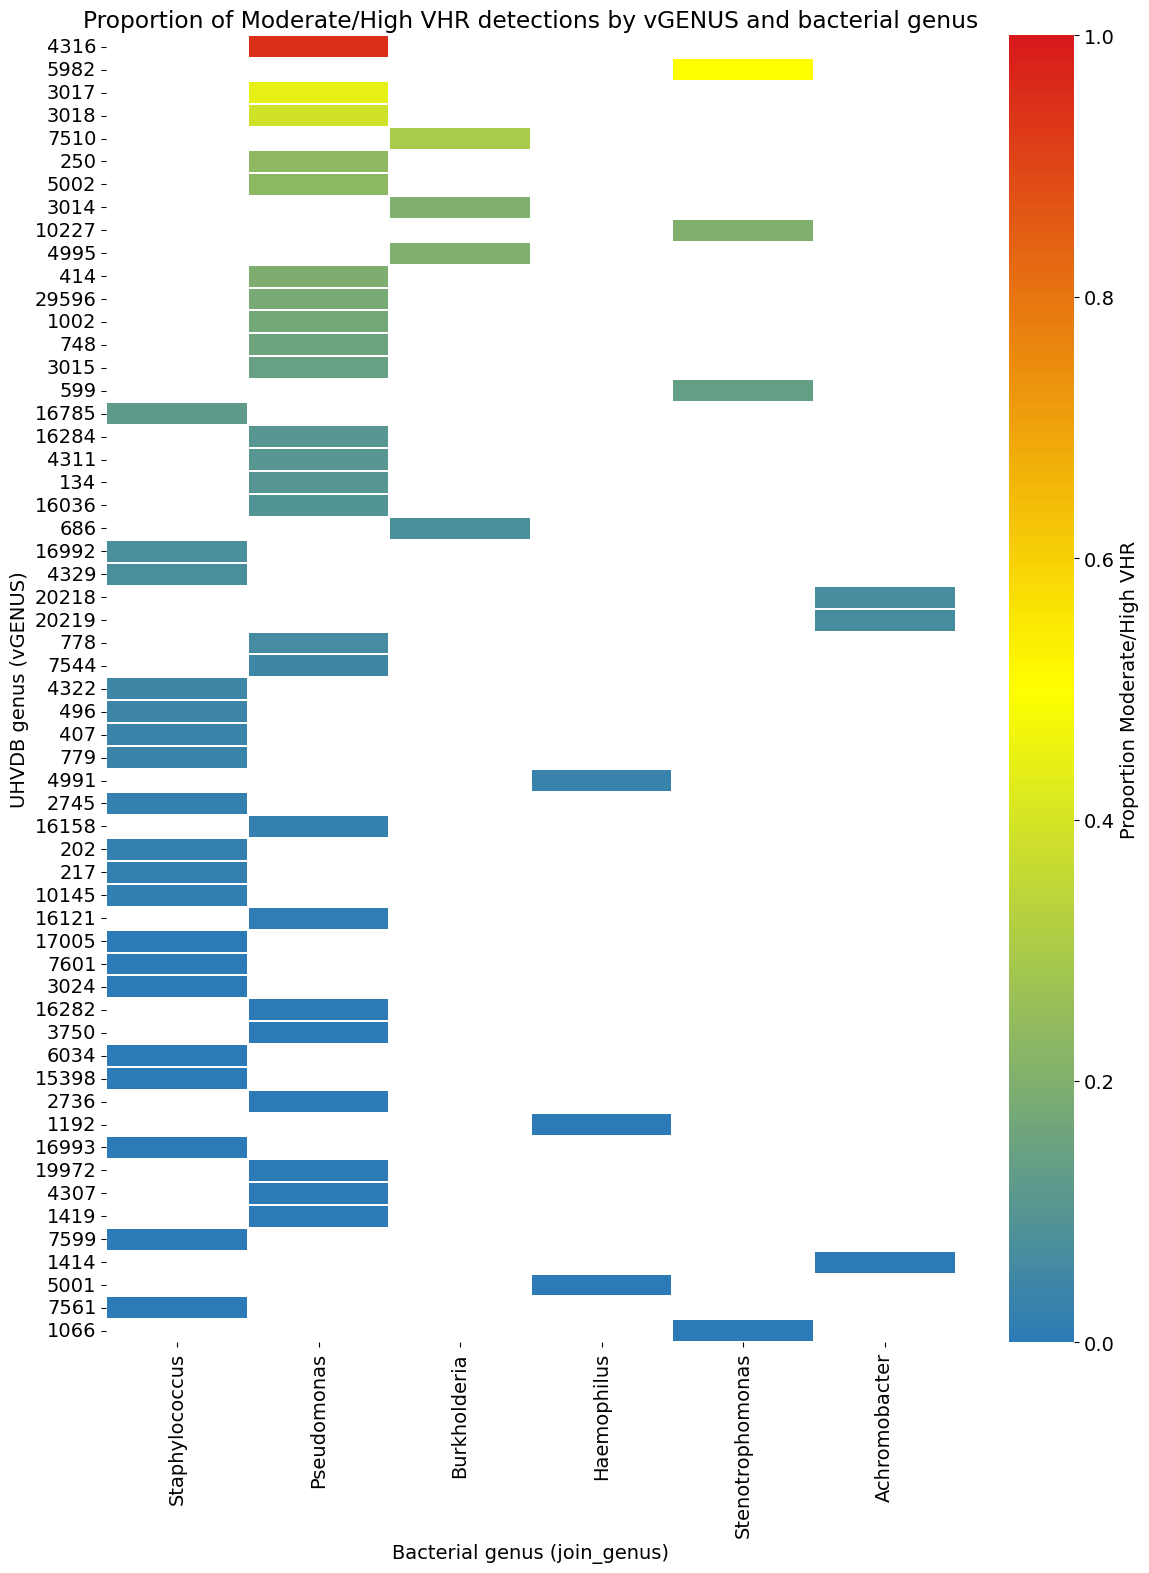

join_genus,vfam,ictv_class,n_detections_in_vfam,n_moderate_or_high_detections,proportion_moderate_or_high
str,str,str,u32,i64,f64
"""Pseudomonas""","""4316""","""Faserviricetes""",21,20,0.952381
"""Stenotrophomonas""","""5982""","""Caudoviricetes""",10,5,0.5
"""Pseudomonas""","""3017""","""Caudoviricetes""",54,24,0.444444
"""Pseudomonas""","""3018""","""Faserviricetes""",18,7,0.388889
"""Burkholderia""","""7510""","""Caudoviricetes""",10,3,0.3
…,…,…,…,…,…
"""Haemophilus""","""5001""","""Caudoviricetes""",24,0,0.0
"""Staphylococcus""","""15398""","""Caudoviricetes""",14,0,0.0
"""Stenotrophomonas""","""1066""","""Caudoviricetes""",10,0,0.0


In [60]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

vfam_vhr_summary = (
    vhr_cats
        .with_columns([
            pl.col('virus_species').str.split('vGENUS-').list[-1].str.split('|').list[0].alias('vfam'),
            pl.col('vhr_category').is_in(['Moderate VHR', 'High VHR']).alias('is_moderate_or_high')
        ])
        .group_by('join_genus', 'vfam', 'ictv_class')
        .agg([
            pl.len().alias('n_detections_in_vfam'),
            pl.col('is_moderate_or_high').cast(pl.Int64).sum().alias('n_moderate_or_high_detections')
        ])
        .with_columns([
            (pl.col('n_moderate_or_high_detections') / pl.col('n_detections_in_vfam')).alias('proportion_moderate_or_high')
        ])
        .sort('proportion_moderate_or_high', descending=True)
        .filter(pl.col('n_detections_in_vfam') >= 10)
 )

# Collapse across ictv_class so each join_genus-vfam pair has one value
vfam_heatmap_df = (
    vfam_vhr_summary
        .group_by(['join_genus', 'vfam'])
        .agg([
            pl.col('n_detections_in_vfam').sum().alias('n_detections_in_vfam'),
            pl.col('n_moderate_or_high_detections').sum().alias('n_moderate_or_high_detections')
        ])
        .with_columns([
            (pl.col('n_moderate_or_high_detections') / pl.col('n_detections_in_vfam')).alias('proportion_moderate_or_high')
        ])
 )

heatmap_pd = (
    vfam_heatmap_df
        .pivot(index='vfam', on='join_genus', values='proportion_moderate_or_high')
        .to_pandas()
        .set_index('vfam')
 )

# Optional ordering for readability
heatmap_pd = heatmap_pd.loc[heatmap_pd.mean(axis=1).sort_values(ascending=False).index]

# Emphasize 50% (0.5) with a bright midpoint color
vhr_cmap = LinearSegmentedColormap.from_list(
    'vhr_emphasis',
    [(0.0, '#2c7bb6'), (0.5, '#ffff00'), (1.0, '#d7191c')]
 )
vhr_norm = TwoSlopeNorm(vmin=0.0, vcenter=0.5, vmax=1.0)

plt.figure(figsize=(12, max(6, 0.28 * heatmap_pd.shape[0])))
sns.heatmap(
    heatmap_pd,
    cmap=vhr_cmap,
    norm=vhr_norm,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Proportion Moderate/High VHR'}
)
plt.title('Proportion of Moderate/High VHR detections by vGENUS and bacterial genus')
plt.xlabel('Bacterial genus (join_genus)')
plt.ylabel('UHVDB genus (vGENUS)')
plt.tight_layout()
plt.show()

vfam_vhr_summary

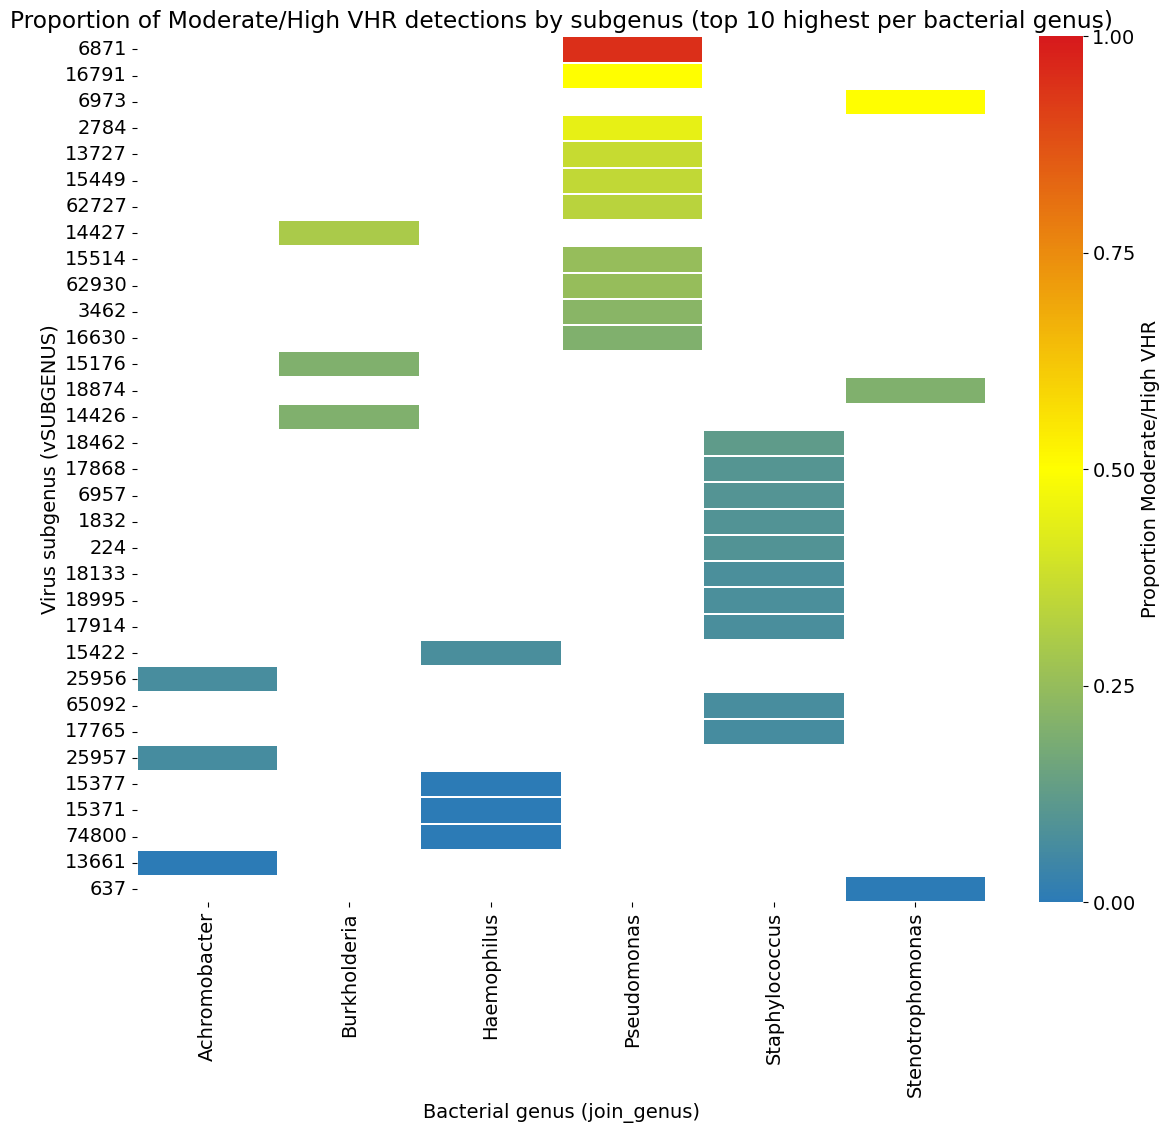

join_genus,vfam,ictv_class,n_detections_in_vfam,n_moderate_or_high_detections,proportion_moderate_or_high
str,str,str,u32,i64,f64
"""Pseudomonas""","""2784""","""Caudoviricetes""",54,24,0.444444
"""Pseudomonas""","""16579""","""Caudoviricetes""",182,1,0.005495
"""Pseudomonas""","""15806""","""Caudoviricetes""",15,0,0.0
"""Burkholderia""","""14427""","""Caudoviricetes""",10,3,0.3
"""Staphylococcus""","""18133""","""Caudoviricetes""",13,1,0.076923
…,…,…,…,…,…
"""Achromobacter""","""25956""","""Caudoviricetes""",15,1,0.066667
"""Pseudomonas""","""15449""","""Caudoviricetes""",54,19,0.351852
"""Staphylococcus""","""18459""","""Caudoviricetes""",12,0,0.0


In [61]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

vfam_vhr_summary = (
    vhr_cats
        .with_columns([
            pl.col('virus_species').str.split('vSUBGENUS-').list[-1].str.split('|').list[0].alias('vfam'),
            pl.col('vhr_category').is_in(['Moderate VHR', 'High VHR']).alias('is_moderate_or_high')
        ])
        .group_by('join_genus', 'vfam', 'ictv_class')
        .agg([
            pl.len().alias('n_detections_in_vfam'),
            pl.col('is_moderate_or_high').cast(pl.Int64).sum().alias('n_moderate_or_high_detections')
        ])
        .with_columns([
            (pl.col('n_moderate_or_high_detections') / pl.col('n_detections_in_vfam')).alias('proportion_moderate_or_high')
        ])
        .filter(pl.col('n_detections_in_vfam') >= 10)
 )

# Collapse across ictv_class so each join_genus-vfam pair has one value
vfam_heatmap_df = (
    vfam_vhr_summary
        .group_by(['join_genus', 'vfam'])
        .agg([
            pl.col('n_detections_in_vfam').sum().alias('n_detections_in_vfam'),
            pl.col('n_moderate_or_high_detections').sum().alias('n_moderate_or_high_detections')
        ])
        .with_columns([
            (pl.col('n_moderate_or_high_detections') / pl.col('n_detections_in_vfam')).alias('proportion_moderate_or_high')
        ])
 )

# Keep top 10 highest Moderate/High proportions within each bacterial genus
TOP_N_SUBGENERA_PER_GENUS = 10
vfam_heatmap_df_top = (
    vfam_heatmap_df
        .sort(
            ['join_genus', 'proportion_moderate_or_high', 'n_detections_in_vfam', 'vfam'],
            descending=[False, True, True, False]
        )
        .with_columns(
            pl.col('vfam').cum_count().over('join_genus').alias('rank_within_genus')
        )
        .filter(pl.col('rank_within_genus') <= TOP_N_SUBGENERA_PER_GENUS)
        .drop('rank_within_genus')
 )

heatmap_pd = (
    vfam_heatmap_df_top
        .pivot(index='vfam', on='join_genus', values='proportion_moderate_or_high')
        .to_pandas()
        .set_index('vfam')
 )

# Order rows by average selected proportion, then by total detections
row_order = (
    vfam_heatmap_df_top
        .group_by('vfam')
        .agg([
            pl.col('proportion_moderate_or_high').mean().alias('mean_selected_proportion'),
            pl.col('n_detections_in_vfam').sum().alias('total_detections')
        ])
        .sort(['mean_selected_proportion', 'total_detections'], descending=[True, True])
        .get_column('vfam')
        .to_list()
 )
heatmap_pd = heatmap_pd.reindex(row_order)

# Fixed color scale on [0, 1]
vmax = 1.0
vcenter = 0.5

vhr_cmap = LinearSegmentedColormap.from_list(
    'vhr_emphasis',
    [(0.0, '#2c7bb6'), (0.5, '#ffff00'), (1.0, '#d7191c')]
 )
vhr_norm = TwoSlopeNorm(vmin=0.0, vcenter=vcenter, vmax=vmax)

plt.figure(figsize=(12, max(6, 0.35 * heatmap_pd.shape[0])))
sns.heatmap(
    heatmap_pd,
    cmap=vhr_cmap,
    norm=vhr_norm,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={
        'label': 'Proportion Moderate/High VHR',
        'ticks': [0.0, 0.25, 0.5, 0.75, 1.0]
    }
)
plt.title(f'Proportion of Moderate/High VHR detections by subgenus (top {TOP_N_SUBGENERA_PER_GENUS} highest per bacterial genus)')
plt.xlabel('Bacterial genus (join_genus)')
plt.ylabel('Virus subgenus (vSUBGENUS)')
plt.tight_layout()
plt.show()

vfam_vhr_summary